Examples of factor ETFs:
- SIZE: iShares MSCI USA Size Factor ETF
- MTUM: iShares MSCI USA Momentum Factor ETF
- VLUE: iShares MSCI USA Value Factor ETF
- QUAL: iShares MSCI USA Quality Factor ETF
- USMV: iShares MSCI USA Min Vol Factor ETF
- HDV: iShares Core High Dividend ETF
- LRGF: iShares US Equity Factor ETF
- INTF: iShares International Equity Factor ETF
- EMGF: iShares Emerging Markets Equity Factor ETF
- SPY: SPDR S&P 500 ETF

In [1]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import datetime as dt
import yfinance as yf
import pandas_datareader
import pandas_datareader.data as web
import sys
import causalnex
from causalnex.structure.dynotears import from_pandas_dynamic
from causalnex.network import BayesianNetwork
import networkx as nx
from copy import deepcopy
import pyagrum as gum
import pyagrum.lib.notebook as gnb
# from causalnex.plots import plot_structure

plt.rcParams['figure.figsize'] = (6,3)

/opt/anaconda3/envs/quant1/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print(f"platform:\t\t{sys.platform}")
print(f"python version:\t\t{sys.version}")
print(f"pandas version:\t\t{pd.__version__}")
print(f"numpy version:\t\t{np.__version__}")
print(f"matplotlib version:\t{matplotlib.__version__}")
print(f"yfinance version:\t{yf.__version__}")
print(f"pd-datareader version:\t{pandas_datareader.__version__}")
print(f"causalnex version:\t{causalnex.__version__}")
print(f"pyAgrum version:\t{gum.__version__}")

platform:		darwin
python version:		3.10.18 (main, Jun  5 2025, 08:37:47) [Clang 14.0.6 ]
pandas version:		1.5.3
numpy version:		1.23.5
matplotlib version:	3.10.5
yfinance version:	0.2.65
pd-datareader version:	0.10.0
causalnex version:	0.12.1
pyAgrum version:	2.2.1


## Section 1 - Data Preparation

In [3]:
# retrieve price data for factor ETFs & indices from Yahoo Finance
tick = ['SIZE', 'MTUM', 'VLUE', 'QUAL', 'USMV', 'HDV',
        # 'LRGF', 'INTF', 'EMGF',
        'SPY', '^VIX']
end = dt.datetime(2025, 9, 30)
start = dt.datetime(2000, 1, 1)
yfin_data = yf.download(tick,
                        start,
                        end,
                        auto_adjust=False,
                        progress=False)['Close']

# tidy column names & ordering
yfin_data = yfin_data.loc[:,tick]
yfin_data.columns.name = None
yfin_data.rename(columns = {
    '^GSPC': 'SP500',
    '^VIX': 'VIX'
    },
    inplace=True)
yfin_data = yfin_data.dropna()
yfin_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3069 entries, 2013-07-18 to 2025-09-29
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SIZE    3069 non-null   float64
 1   MTUM    3069 non-null   float64
 2   VLUE    3069 non-null   float64
 3   QUAL    3069 non-null   float64
 4   USMV    3069 non-null   float64
 5   HDV     3069 non-null   float64
 6   SPY     3069 non-null   float64
 7   VIX     3069 non-null   float64
dtypes: float64(8)
memory usage: 215.8 KB


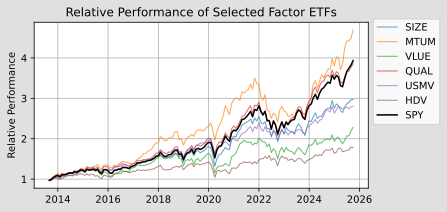

In [4]:
# plot relative performance for selected ETFs
plt.subplots()
plt.plot((1 + yfin_data.iloc[:,:-2].resample('M').last().pct_change().dropna()).cumprod(),
         alpha=0.7,
         linewidth=1.0,
         label=yfin_data.columns[:-2])
plt.plot((1 + yfin_data.loc[:,'SPY'].resample('M').last().pct_change().dropna()).cumprod(),
         c='black',
         label='SPY')
plt.ylabel('Relative Performance')
plt.legend(bbox_to_anchor=(1, 1.05))
plt.title('Relative Performance of Selected Factor ETFs')
plt.grid()
plt.show()

In [5]:
# fetch macroeconomic data from FRED
datasets_fred = [
    'DFF',
    'M2REAL',
    'USEPUINDXD'
    ]

fred_data = pd.DataFrame()
for f in datasets_fred:
    fred_data[f] = web.DataReader(f,'fred',start,end)
fred_data.rename(columns = {
    'DFF': 'FEDRATE',
    'M2REAL': 'MONYSPPLY',
    'USEPUINDXD': 'POLICY'
    },
    inplace=True)
fred_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9405 entries, 2000-01-01 to 2025-09-30
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   FEDRATE    9405 non-null   float64
 1   MONYSPPLY  308 non-null    float64
 2   POLICY     9405 non-null   float64
dtypes: float64(3)
memory usage: 293.9 KB


In [6]:
# concatenate into 1 dataframe with monthly data
df = pd.concat([yfin_data, fred_data], axis=1, join='outer')
df = df.dropna()

# create a 1 step ahead forecast variable
df['SPY+1'] = df['SPY'].shift(-1)
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 92 entries, 2013-08-01 to 2025-07-01
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   SIZE       92 non-null     float64
 1   MTUM       92 non-null     float64
 2   VLUE       92 non-null     float64
 3   QUAL       92 non-null     float64
 4   USMV       92 non-null     float64
 5   HDV        92 non-null     float64
 6   SPY        92 non-null     float64
 7   VIX        92 non-null     float64
 8   FEDRATE    92 non-null     float64
 9   MONYSPPLY  92 non-null     float64
 10  POLICY     92 non-null     float64
 11  SPY+1      92 non-null     float64
dtypes: float64(12)
memory usage: 9.3 KB


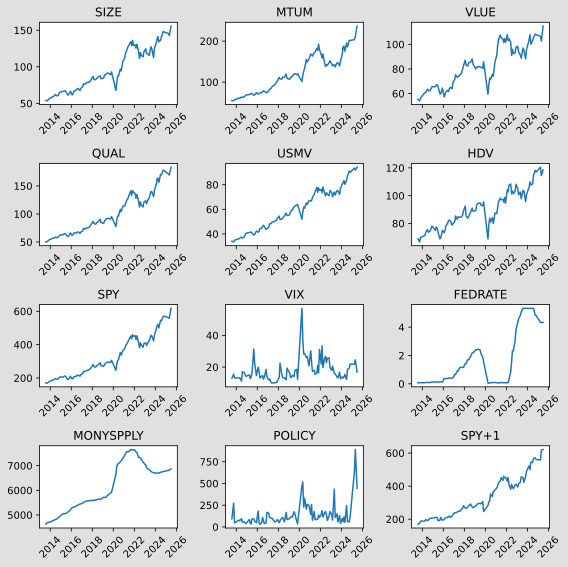

In [7]:
# quick visualization of data
rows = 4
cols = 3

fig, axs = plt.subplots(rows, cols, figsize=(8,8))
for r in range(rows):
    for c in range(cols):
        axs[r,c].plot(df.iloc[:, cols*r+c])
        axs[r,c].set_title(df.columns[cols*r+c])
        axs[r,c].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [8]:
# generate a log returns dataframe
ret_df = np.log(df).diff().dropna()

# standardize log returns & visualize
ret_df_norm = (ret_df - ret_df.mean()) / ret_df.std()

# # visualization of standardized data
# fig, axs = plt.subplots(rows, cols, figsize=(8,8))
# for r in range(rows):
#     for c in range(cols):
#         axs[r,c].plot(ret_df_norm.iloc[:, cols*r+c])
#         axs[r,c].set_title(ret_df_norm.columns[cols*r+c])
#         axs[r,c].tick_params(axis='x', rotation=30)
# plt.tight_layout()
# plt.show()

## Section 2 - Bayesian Network

### 2.1. Dynamic BN (DYNOTEARS) Structure Learning

In [9]:
# copy dataframe & reset index
ret_df_norm1 = ret_df_norm.copy()
ret_df_norm1 = ret_df_norm1.reset_index(drop=True)

# causal structure learning w/ DYNOTEARS
csl_grph = from_pandas_dynamic(
    ret_df_norm1,
    1,
    lambda_w=0.1,
    lambda_a=0.1,
    w_threshold=0.1,
    # to ensure no future forecast going back in time
    tabu_edges=[(1, "SPY+1", "SPY"),
                (1, "SPY+1", "VIX"),
                (1, "SPY+1", "MTUM"),
                (1, "SPY+1", "SIZE"),
                (1, "SPY+1", "QUAL"),
                (1, "SPY+1", "VLUE"),
                (1, "SPY+1", "USMV"),
                (1, "SPY+1", "HDV")]
)

# inspect the edges
grph = deepcopy(csl_grph)
for e in grph.edges:
    print(e)

('SIZE_lag0', 'VLUE_lag0')
('SIZE_lag0', 'USMV_lag0')
('SIZE_lag0', 'HDV_lag0')
('SIZE_lag0', 'SPY_lag0')
('SIZE_lag0', 'POLICY_lag0')
('VLUE_lag0', 'HDV_lag0')
('QUAL_lag0', 'MTUM_lag0')
('QUAL_lag1', 'POLICY_lag0')
('USMV_lag0', 'SPY_lag0')
('HDV_lag0', 'USMV_lag0')
('HDV_lag0', 'MONYSPPLY_lag0')
('HDV_lag0', 'SPY+1_lag0')
('SPY_lag0', 'MTUM_lag0')
('SPY_lag0', 'QUAL_lag0')
('SPY_lag1', 'VIX_lag0')
('VIX_lag0', 'SIZE_lag0')
('VIX_lag0', 'HDV_lag0')
('VIX_lag0', 'FEDRATE_lag0')
('VIX_lag1', 'VIX_lag0')
('FEDRATE_lag1', 'MONYSPPLY_lag0')
('MONYSPPLY_lag0', 'FEDRATE_lag0')
('MONYSPPLY_lag0', 'POLICY_lag0')
('MONYSPPLY_lag1', 'SIZE_lag0')
('MONYSPPLY_lag1', 'MONYSPPLY_lag0')
('POLICY_lag1', 'POLICY_lag0')
('POLICY_lag1', 'SPY+1_lag0')


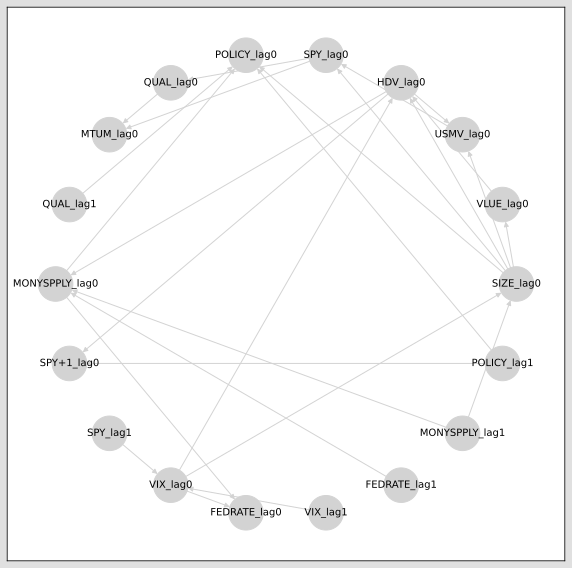

In [10]:
# visualize the DAG
plt.subplots(figsize=(10,10))
G = nx.DiGraph()
G.add_edges_from(grph.edges)
pos = nx.circular_layout(G)
nx.draw_networkx(G, pos,
                 node_color='lightgrey',
                 node_size=1200,
                 edge_color='lightgrey',
                 font_size=10,
                 font_weight=14)
plt.show()

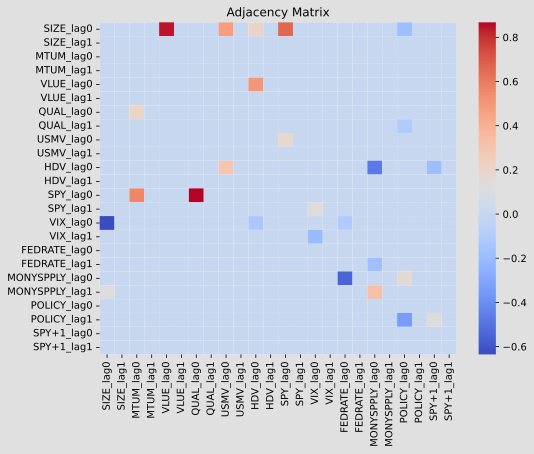

In [11]:
# visualize adjacency matrix
adj_mtx = nx.adjacency_matrix(grph)
adj_mtx_df = pd.DataFrame(data = adj_mtx.toarray(),
                          columns = grph.nodes,
                          index = grph.nodes)
from seaborn import heatmap
plt.subplots(figsize=(8,6))
heatmap(adj_mtx_df,
        linecolor='lightgrey',
        linewidths=0.01,
        cmap='coolwarm')
plt.title('Adjacency Matrix')
plt.show()

### 2.2. Parameter Learning

In [12]:
# create a new BN to be parameterized
bn = BayesianNetwork(grph.get_largest_subgraph())

In [13]:
# create a discretized returns dataframe (based on quantiles)

temp_ret_df = ret_df_norm1.copy()
temp_ret_df.columns = [f'{i}_lag0' for i in ret_df_norm1.columns]

# generate lag1 data
for j in temp_ret_df.columns:
    temp_ret_df[f'{j[:-1]}1'] = temp_ret_df[j].shift(-1).fillna(0)

# select columns that are present as nodes
slctd_cols = []

for e in grph.edges:
    for f in range(2):
        if e[f] not in slctd_cols:
            slctd_cols.append(e[f])
        else:
            continue

dscrtz_ret_df = pd.DataFrame()
for x in slctd_cols:
    temp = []
    for y in range(temp_ret_df.shape[0]):
        if temp_ret_df[x].iloc[y] <= temp_ret_df[x].quantile(0.25):
            temp.append(0)
        elif temp_ret_df[x].iloc[y] >= temp_ret_df[x].quantile(0.75):
            temp.append(2)
        else:
            temp.append(1)
    dscrtz_ret_df[x] = temp

In [14]:
# fit parameters
bn = bn.fit_node_states(dscrtz_ret_df)
bn = bn.fit_cpds(dscrtz_ret_df,
                 method = 'BayesianEstimator',
                 bayes_prior = 'K2')

In [15]:
# inspect CPTs (& store in a dict for later)
CPT = {}

for i in dscrtz_ret_df.columns:
    CPT[i] = bn.cpds[i]
    print(bn.cpds[i])

MONYSPPLY_lag1         0                         1                      \
VIX_lag0               0       1         2       0         1         2   
SIZE_lag0                                                                
0               0.285714  0.3125  0.555556  0.0625  0.083333  0.642857   
1               0.428571  0.3750  0.333333  0.5000  0.708333  0.285714   
2               0.285714  0.3125  0.111111  0.4375  0.208333  0.071429   

MONYSPPLY_lag1         2                      
VIX_lag0               0         1         2  
SIZE_lag0                                     
0               0.111111  0.142857  0.555556  
1               0.333333  0.500000  0.333333  
2               0.555556  0.357143  0.111111  
SIZE_lag0         0         1         2
VLUE_lag0                              
0          0.730769  0.125000  0.038462
1          0.230769  0.729167  0.269231
2          0.038462  0.145833  0.692308
HDV_lag0          0                   1                             2  \


In [ ]:
# have a look at one of the CPTs for the forecasted SPY
CPT['SPY+1_lag0']

HDV_lag0            0                     1                             2  \
POLICY_lag1         0    1      2         0         1         2         0   
SPY+1_lag0                                                                  
0            0.222222  0.2  0.375  0.250000  0.178571  0.357143  0.363636   
1            0.444444  0.4  0.250  0.666667  0.571429  0.500000  0.272727   
2            0.333333  0.4  0.375  0.083333  0.250000  0.142857  0.363636   

HDV_lag0                    
POLICY_lag1         1    2  
SPY+1_lag0                  
0            0.454545  0.2  
1            0.363636  0.4  
2            0.181818  0.4

## Section 3 - Constructing An Influence Diagram

In [17]:
# create an ID object
ID = gum.InfluenceDiagram()

# add a Action node with 5 fractions of wealth to invest
i = gum.LabelizedVariable("InvestFrac", "Fraction of wealth invested", 0)
pct = ["0%", "25%", "50%", "75%", "100%"]
for p in pct:
    i.addLabel(p)
inv = ID.addDecisionNode(i)

# add a Utility node
u = gum.LabelizedVariable("Utility", "Portfolio utility", 1)
util = ID.addUtilityNode(u)

# add chance nodes
for k in CPT.keys():
    n = gum.LabelizedVariable(f"{k}", f"{k}", 0).addLabel("0").addLabel("1").addLabel("2")
    m = ID.addChanceNode(n)
    if k == 'SPY+1_lag0':
        # connect forecasted SPY to Utility node
        ID.addArc(m, util)
        continue

# specifiy the other arcs / edges
for e in grph.edges:
    ID.addArc(e[0], e[1])

# connect Action node to Utility nodes
ID.addArc(inv, util)

# add probabilities
for s in slctd_cols:
    ID.cpt(s).fillWith(CPT[s].values.ravel())

# inspect ID structure
from IPython.display import Image
ID

(pyagrum.InfluenceDiagram@0x1682bbc00) Influence Diagram{
  chance: 18,
  utility: 1,
  decision: 1,
  arcs: 28,
  domainSize: 10^9.28715
}